In [1]:
pip install pandas matplotlib sklearn.decomposition sklearn.preprocessing sklearn.datasets seaborn numpy

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sklearn.decomposition (from versions: none)
ERROR: No matching distribution found for sklearn.decomposition


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons

### Task 1. Setting

In [3]:
# Read the CSV file
url = 'https://www.statlearning.com/s/Ch10Ex11.csv'
genes = pd.read_csv(url, header=None)

# Transpose the dataframe and convert to pandas DataFrame
genes = genes.T
genes = pd.DataFrame(genes)
print('Dimensions of genes dataframe:', genes.shape)

# Define health_status
health_status = ['healthy'] * 20 + ['diseased'] * 20

Dimensions of genes dataframe: (40, 1000)


In [4]:
genes.head()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,-0.961933,-0.292526,0.258788,-1.152132,0.195783,0.030124,0.085418,1.116610,-1.218857,1.267369,...,1.325041,-0.116171,-1.470146,-0.379272,-1.465006,1.075148,-1.226125,-3.056328,1.450658,0.717977
1,0.441803,-1.139267,-0.972845,-2.213168,0.593306,-0.691014,-1.113054,1.341700,-1.277279,-0.918349,...,0.740838,-0.162392,-0.633375,-0.895521,2.034465,3.003267,-0.501702,0.449889,1.310348,0.763482
2,-0.975005,0.195837,0.588486,-0.861525,0.282992,-0.403426,-0.677969,0.103278,-0.558925,-1.253500,...,-0.435533,-0.235912,1.446660,-1.127459,0.440849,-0.123441,-0.717430,1.880362,0.383837,0.313576
3,1.417504,-1.281121,-0.800258,0.630925,0.247147,-0.729859,-0.562929,0.390963,-1.344493,-1.067114,...,-3.065529,1.597294,0.737478,-0.631248,-0.530442,-1.036740,-0.169113,-0.742841,-0.408860,-0.326473
4,0.818815,-0.251439,-1.820398,0.951772,1.978668,-0.364099,0.938194,-1.927491,1.159115,-0.240638,...,-2.378938,-0.086946,-0.122342,1.418029,1.075337,-1.270604,0.599530,2.238346,-0.471111,-0.158700


#### Task 1. Question 1

In [5]:
variance = genes.var()
variance

0      0.729974
1      0.859665
2      0.893806
3      1.389233
4      1.067273
         ...   
995    1.115142
996    0.666400
997    1.707376
998    1.244223
999    0.856134
Length: 1000, dtype: float64

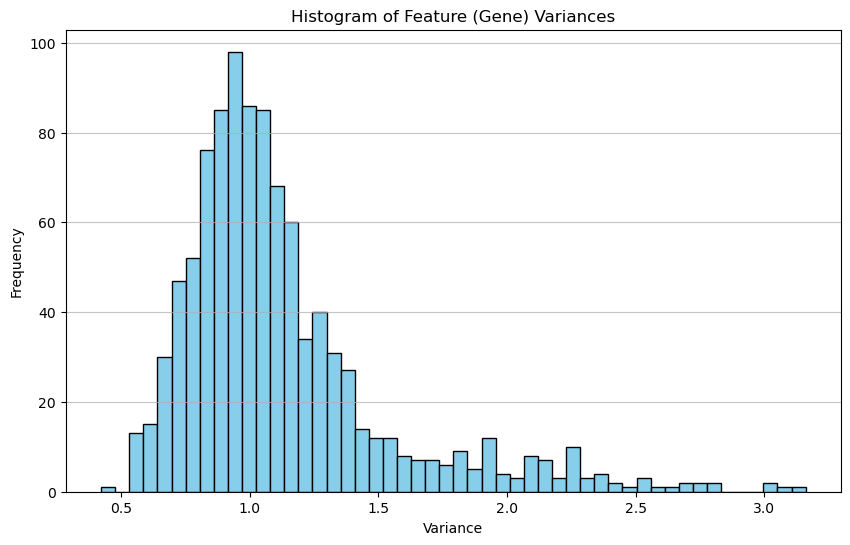

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(variance, bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Feature (Gene) Variances')
plt.xlabel('Variance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [7]:
min = variance.min()
max = variance.max()
ratio = max / min

print(f"Minimum Variance: {min:.2f}")
print(f"Maximum Variance: {max:.2f}")
print(f"Ratio (Max/Min): {ratio:.2f}")

Minimum Variance: 0.42
Maximum Variance: 3.16
Ratio (Max/Min): 7.47


### Interpretation

The features are plus minus similarly scaled, the ratio between min and max values is around 7.5 which seems not to be extremely large. So, in other words the values are approximately in the same range/measure. No standardization. 

#### Task 1. Question 2

In [8]:
# Apply PCA and calculate the principal components as X_pca
pca = PCA() #definition of the model
pca

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [9]:
pca.fit(genes)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [10]:
pca.components_

array([[-0.00243466, -0.0020166 ,  0.01123384, ...,  0.00131733,
        -0.01019835, -0.00826155],
       [ 0.0307458 ,  0.02592759,  0.0039378 , ..., -0.00310033,
        -0.0351605 , -0.01567738],
       [ 0.00935993,  0.05030098,  0.01456492, ...,  0.04745529,
         0.04360466,  0.00903374],
       ...,
       [-0.0127544 ,  0.03141046, -0.02585725, ..., -0.00021884,
        -0.02111978,  0.00321903],
       [ 0.00202144, -0.01083775,  0.00088009, ...,  0.01135126,
        -0.00119929,  0.02803129],
       [-0.10883221, -0.02721165, -0.02965639, ...,  0.00300051,
         0.01227319,  0.00410677]], shape=(40, 1000))

In [11]:
print(f"Number of components: {pca.n_components_}")

Number of components: 40


In [12]:
total_variance = np.var(genes, axis=0).sum()
print(f'Total variance in original data: {total_variance:.2f}')
total_variance

Total variance in original data: 1097.44


np.float64(1097.4442472458509)

In [13]:
# Variance explained by each principal component (in absolute terms)
print('Variance explained by each PC:')
pca.explained_variance_

Variance explained by each PC:


array([1.42585065e+02, 3.68227764e+01, 3.52214281e+01, 3.40023363e+01,
       3.30865111e+01, 3.24935847e+01, 3.17473208e+01, 3.11058033e+01,
       3.07961784e+01, 3.03187793e+01, 3.01238222e+01, 2.98143151e+01,
       2.91847948e+01, 2.84558903e+01, 2.78525905e+01, 2.72059896e+01,
       2.70399695e+01, 2.65369018e+01, 2.61734465e+01, 2.55621828e+01,
       2.53850673e+01, 2.51871485e+01, 2.45981741e+01, 2.41467399e+01,
       2.36581587e+01, 2.32127076e+01, 2.31178883e+01, 2.24187655e+01,
       2.20992371e+01, 2.16749418e+01, 2.13093570e+01, 2.08604971e+01,
       2.05237775e+01, 2.02075027e+01, 1.90533609e+01, 1.89971847e+01,
       1.82072548e+01, 1.76632613e+01, 1.71331314e+01, 2.79339353e-29])

In [14]:
print('Proportion of variance explained by each PC:')
pca.explained_variance_ratio_

Proportion of variance explained by each PC:


array([1.26676539e-01, 3.27143790e-02, 3.12916966e-02, 3.02086215e-02,
       2.93949769e-02, 2.88682047e-02, 2.82052030e-02, 2.76352610e-02,
       2.73601816e-02, 2.69360470e-02, 2.67628417e-02, 2.64878670e-02,
       2.59285836e-02, 2.52810046e-02, 2.47450163e-02, 2.41705580e-02,
       2.40230612e-02, 2.35761218e-02, 2.32532180e-02, 2.27101544e-02,
       2.25528000e-02, 2.23769634e-02, 2.18537022e-02, 2.14526355e-02,
       2.10185663e-02, 2.06228152e-02, 2.05385751e-02, 1.99174549e-02,
       1.96335770e-02, 1.92566213e-02, 1.89318256e-02, 1.85330460e-02,
       1.82338949e-02, 1.79529076e-02, 1.69275359e-02, 1.68776274e-02,
       1.61758317e-02, 1.56925327e-02, 1.52215506e-02, 2.48172852e-32])

In [15]:
n_components_90 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.90)[0][0] + 1
print('number of components needed to explain 90% of variance:')
n_components_90

number of components needed to explain 90% of variance:


np.int64(33)

In [16]:
print(f'PC1 explains {pca.explained_variance_ratio_[0] * 100:.1f}% of total variance')
print(f'PC2 explains {pca.explained_variance_ratio_[1] * 100:.1f}% of total variance')

PC1 explains 12.7% of total variance
PC2 explains 3.3% of total variance


#### Task 1. Question 3

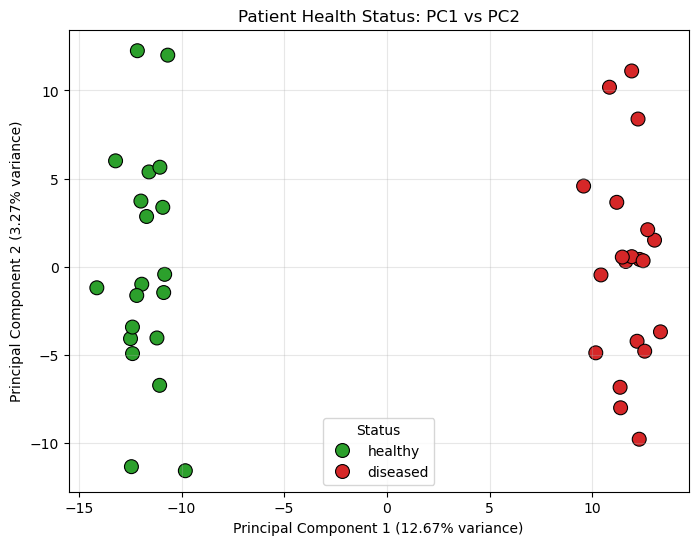

In [17]:
X_pca = pca.transform(genes)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=health_status, 
    palette=['#2ca02c', '#d62728'], # green for healthy, red for diseased
    s=100, 
    edgecolor='black'
)

plt.title('Patient Health Status: PC1 vs PC2')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(title='Status')
plt.grid(alpha=0.3)
plt.show()

### Interpretation

The first component (X-axis) catches the most variation (12.67%) and horizontally separates the points with labels 'healthy' and 'diseased' by forming two separate clusters that means it has a good explanatory power to divide patients. We observe almost no overlapping among two groups: this indicates that the first two components help distinguish healthy from diseased patients quite well. As for outperforming, 1 PC separates the groups more clearly (because of horizontally division) than 2 PC.

#### Task 1. Question 4

In [18]:
pc1_loadings = pca.components_[0]

loadings_series = pd.Series(pc1_loadings, index=[f'Gene_{i}' for i in range(genes.shape[1])])

top_genes = loadings_series.abs().sort_values(ascending=False).head(10)

print("Top 10 genes most strongly influencing the separation:")
print(top_genes)

Top 10 genes most strongly influencing the separation:
Gene_599    0.114243
Gene_583    0.110398
Gene_548    0.108329
Gene_539    0.108125
Gene_501    0.107460
Gene_581    0.106549
Gene_564    0.106271
Gene_567    0.106188
Gene_528    0.104163
Gene_598    0.103821
dtype: float64


### Explanation
we use absolute values of genes weights/loadings regardless of its direction (whether positive or negative). These loadings allow PC1 to explain the most share of variation, because these genes loadings show the most difference between healthy and unhealthy patients what makes PC1 so valuable and top-tier component.

### Task 2. Setting

In [19]:
# Data generation with mixed correlation structure

rng = np.random.default_rng(seed=20260218)  # for reproducibility
n = 100
p = 50

# Create 5 groups of 10 correlated features each
# Within each group, features are correlated with each other
# Between groups, features are independent

X = np.zeros((n, p))

# Generate 5 independent latent factors (one per group)
n_groups = 5
features_per_group = 10
latent_factors = rng.normal(loc=0.0, scale=1.0, size=(n, n_groups))

for group in range(n_groups):
    start_idx = group * features_per_group
    end_idx = start_idx + features_per_group
    
    # Each feature in the group is the latent factor plus independent noise
    # This creates correlation within the group
    for i in range(features_per_group):
        noise = rng.normal(loc=0.0, scale=0.5, size=n)  # smaller noise = higher correlation
        X[:, start_idx + i] = latent_factors[:, group] + noise

print(f'Generated data shape: {X.shape}')
print(f'Data structure: {n_groups} groups of {features_per_group} correlated features each')

Generated data shape: (100, 50)
Data structure: 5 groups of 10 correlated features each


In [20]:
X = pd.DataFrame(X)
X

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.384798,-1.454877,0.333350,-0.488071,-0.967823,-0.363256,-0.474763,-0.087607,-0.393802,0.357167,...,1.582077,0.198182,-0.514102,1.122053,-0.374632,-0.125533,0.878966,1.391841,0.801873,0.588994
1,0.631913,0.338981,0.686785,1.239749,0.115173,-0.456545,0.976171,0.707561,0.247202,0.381006,...,-2.192278,-1.355826,-1.537528,-0.974849,-1.244653,-0.578871,-1.240732,-1.487968,-1.239029,-1.314116
2,-1.297177,-0.721964,-0.776274,-1.145513,0.149156,-0.366769,-0.735085,-0.526603,-0.557747,-0.422784,...,0.233447,-0.050094,0.362227,0.279579,-0.282615,1.052930,0.731887,0.616095,0.186001,0.454739
3,0.971161,0.505840,1.214329,1.037637,1.123762,0.267701,1.381696,1.791252,1.220410,1.535674,...,0.553797,1.253213,1.095024,0.624684,0.740377,1.491411,0.795990,0.682150,1.093840,1.216960
4,0.937495,0.158061,1.247853,-0.133153,-0.311677,-0.103894,0.244711,0.486641,-0.073402,1.109776,...,0.801729,1.042451,0.523950,0.237264,0.516223,0.592470,1.435925,-0.119122,0.594394,0.667160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.157748,0.329563,1.629562,1.854669,0.065175,1.438224,1.533129,0.924633,1.281479,0.525586,...,-0.975140,-0.244499,-1.077111,0.081778,0.055326,0.013582,-0.565796,-0.884058,0.058131,0.202347
96,0.042133,-0.695191,-1.281760,-0.849729,-1.330529,-0.896924,-0.695960,-0.658178,-0.389505,-0.861543,...,-0.399764,-0.190734,-0.976706,-1.430844,-0.073344,-0.236665,-0.413703,-0.253126,-0.981196,-1.471132
97,-0.802925,-0.713938,-1.173729,-1.029512,-1.275189,-0.144052,-0.247421,-0.071382,-1.394319,-1.074119,...,-0.656863,-0.428962,-0.080225,0.134605,-0.214544,-0.550916,-0.263554,0.065597,-0.529497,-0.228568
98,-2.748782,-2.863486,-2.893180,-1.678434,-2.837523,-2.538374,-2.490245,-2.534559,-3.528377,-1.541714,...,-0.005126,0.467401,0.046333,-0.393604,0.098833,0.458881,0.144082,0.784918,0.390225,-0.217396


#### Task 2. Question 1

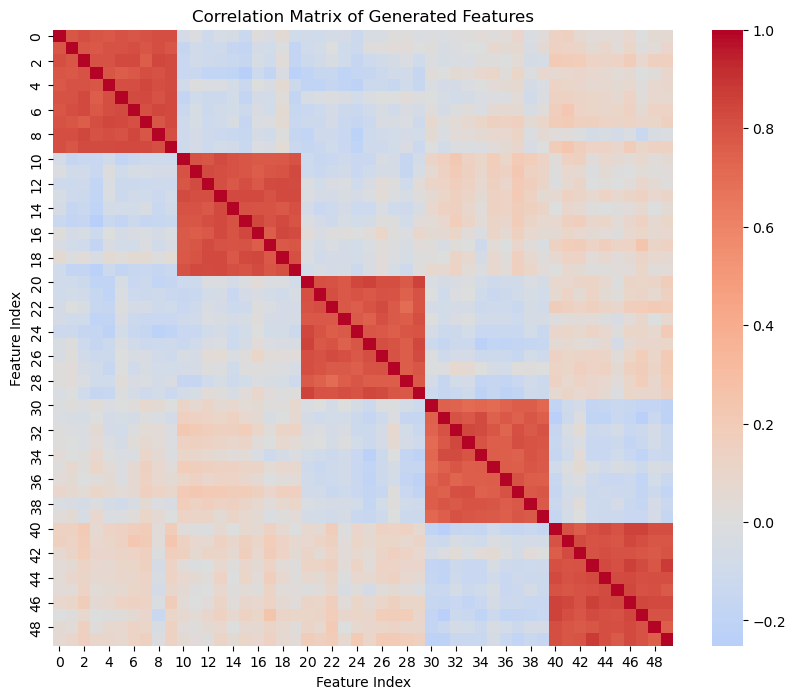

In [21]:
corr_matrix = np.corrcoef(X, rowvar=False)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)

plt.title('Correlation Matrix of Generated Features')
plt.xlabel('Feature Index')
plt.ylabel('Feature Index')
plt.show()

### Explanation
The correlation matrix matches perfect with the built dataset. Each 10 features are created based on the same latent factor (according to the given code for setting), that means they should be highly correlated between each other. On the other side, these groups of features are independent to others because each 10 groups have a certain latent factor. So, between 0-9 groups correlation is around 70-80% like for 10-19, 20-29 and so on.

#### Task 2. Question 2

In [22]:
# Apply PCA and calculate the principal components as X_pca
pca = PCA() #definition of the model
pca

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [23]:
pca.fit(X)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [24]:
pca.components_

array([[ 0.21907207,  0.22124319,  0.24986312, ...,  0.07315316,
         0.0857604 ,  0.10169662],
       [-0.13965794, -0.12363702, -0.13162266, ...,  0.17158334,
         0.14081853,  0.17208908],
       [ 0.12986211,  0.10771589,  0.1383668 , ...,  0.18051438,
         0.16797309,  0.1869368 ],
       ...,
       [-0.01659779, -0.18268789,  0.07119334, ..., -0.00790662,
        -0.28920929,  0.08998027],
       [-0.0564379 ,  0.11189182, -0.22926831, ..., -0.07805279,
         0.20580934,  0.06500589],
       [ 0.06215408,  0.1077796 , -0.10228808, ...,  0.31654932,
         0.01574419,  0.10101949]], shape=(50, 50))

In [25]:
print(f"Number of components: {pca.n_components_}")

Number of components: 50


In [26]:
n_components_90 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.90)[0][0] + 1
print('number of components needed to explain 90% of variance:')
n_components_90

number of components needed to explain 90% of variance:


np.int64(15)

 to explain the 90% of variation we have to include 15 components

#### Task 2. Question 3

Variance explained by first 5 components: 82.49%
Variance explained by 6th component: 1.01%
Variance explained by 7th component: 0.93%
...


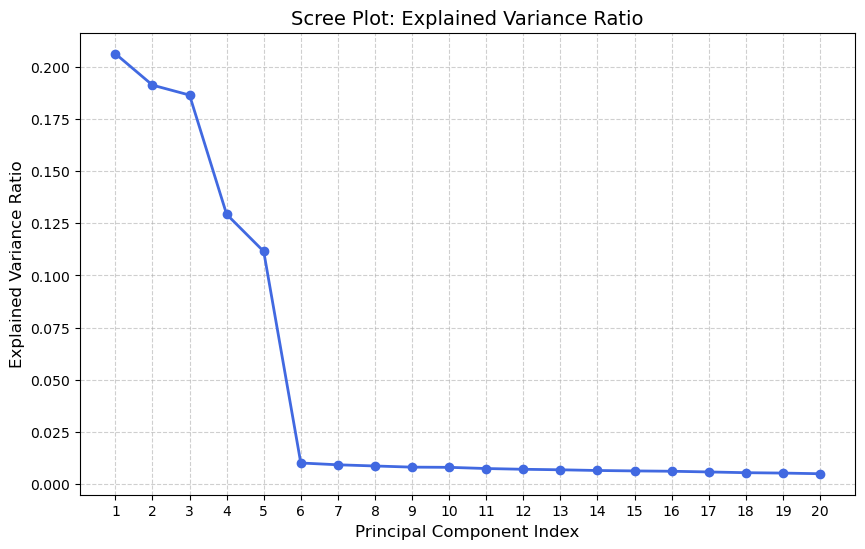

In [27]:
evr = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), evr[:20], marker='o', linestyle='-', color='royalblue', linewidth=2)

plt.title('Scree Plot: Explained Variance Ratio', fontsize=14)
plt.xlabel('Principal Component Index', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.xticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.6)

print(f"Variance explained by first 5 components: {sum(evr[:5]):.2%}")
print(f"Variance explained by 6th component: {evr[5]:.2%}")
print(f"Variance explained by 7th component: {evr[6]:.2%}")
print("...")


Interpretation:
The "Elbow" occurs at the 5th component. There is a sharp drop in explained variance after PC5, followed by a plain line. This tells us the data has exactly 5 meaningful underlying structures (which are actually latent factors), matching our data generating process of 5 groups  


#### Task 2. Question 4

### Splitting data on train/test

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test = train_test_split(X, test_size=0.2, random_state=2026)

train_errors = []
test_errors = []
components_range = range(1, 21)

for k in components_range:
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)       
    
    X_train_rec = pca.inverse_transform(X_train_pca)
    X_test_rec = pca.inverse_transform(X_test_pca)
    

    train_errors.append(mean_squared_error(X_train, X_train_rec))
    test_errors.append(mean_squared_error(X_test, X_test_rec))

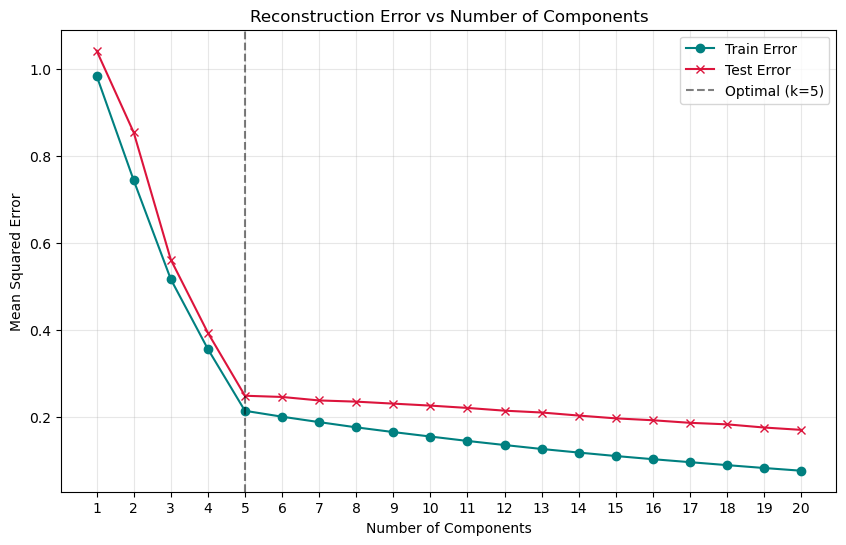

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(components_range, train_errors, label='Train Error', marker='o', color='teal')
plt.plot(components_range, test_errors, label='Test Error', marker='x', color='crimson')

plt.title('Reconstruction Error vs Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Mean Squared Error')
plt.xticks(components_range)
plt.axvline(x=5, color='black', linestyle='--', alpha=0.5, label='Optimal (k=5)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation and final verdict

As is mentioned above, expectedly the first 5PC catch the most variation and, consequently, are the most critical for the prediction problem. The chart shows a sharp drop in MSE with each additional component until the 6th PC is included. After that point, the test error begins to increase incrementally, and the marginal reduction in error becomes insignificant. This result ideally alligns with our data generating process where the five groups are defined by distinct correlation structures, and the ten features within each group are highly correlated due to a shared latent factor. So, I'd pick 5 components as a benchmark for this case. They distinguish these 5 actual different groups filtering out the noise from additional features which in ML problem may make worse because of the curse of dimensionality. 

### Task 3. Setting

In [30]:
# Data generation
import numpy as np

rng = np.random.default_rng(seed=20260218)  # for reproducibility
n = 100
p = 50
X = rng.normal(loc=0.0, scale=1.0, size=(n, p))  # population covariance = I_p

In [31]:
X = pd.DataFrame(X)
X.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.153577,1.104088,-0.961499,0.679979,0.606082,0.184501,-0.956126,-0.451611,1.586541,-1.443232,...,-0.412744,-0.122612,-1.923549,-0.454606,-1.107454,0.651146,-1.056070,-0.076873,0.010517,-1.042731
1,0.206094,-1.078723,-0.268813,0.455106,0.451184,0.049352,0.906154,1.652640,0.915285,0.124265,...,-0.818376,1.066554,0.187313,-0.182276,1.889243,-1.407971,0.021798,0.656405,-0.500722,-0.184338
2,-0.517987,-2.834342,-1.228624,0.441886,-0.964421,-1.270723,0.328814,2.642297,0.821711,-0.880756,...,-1.254016,-1.439954,0.328902,1.033440,-0.418729,3.029195,-0.877462,-0.512888,-0.265552,1.030021
3,1.646534,1.828047,0.130979,0.021146,-1.417273,-1.146278,0.716322,0.300310,-0.555588,1.225726,...,0.134762,-2.017088,-0.081546,0.316113,-0.402806,-0.163730,0.299514,0.443977,-1.130790,0.778799
4,1.607836,0.235867,0.587201,0.439150,1.473340,-0.842396,0.589908,-1.255600,0.764350,-0.777223,...,0.728861,0.971764,-1.129837,0.576264,-0.840156,-0.273669,-0.107250,0.763049,0.728833,0.507597


#### Task 3. Question 1

In [32]:
# Apply PCA and calculate the principal components as X_pca
pca = PCA() #definition of the model
pca

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [33]:
pca.fit(X)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [34]:
pca.components_

array([[ 0.0814241 ,  0.28091137,  0.026565  , ..., -0.03422767,
         0.10806463,  0.11457484],
       [-0.18744434,  0.11424391, -0.11586138, ..., -0.23827015,
        -0.14458619, -0.0480615 ],
       [-0.01275349, -0.1075428 ,  0.13835966, ..., -0.15166943,
        -0.07031982,  0.20405282],
       ...,
       [-0.11018075,  0.14061469, -0.02715794, ...,  0.22115322,
        -0.00124033,  0.21170951],
       [-0.08928195, -0.01269189, -0.15660892, ...,  0.0497607 ,
         0.2545055 ,  0.12621961],
       [ 0.11460027, -0.03964579, -0.12127313, ...,  0.19875727,
        -0.01149787,  0.09864629]], shape=(50, 50))

In [35]:
print(f"Number of components: {pca.n_components_}")

Number of components: 50


In [36]:
n_components_90 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.90)[0][0] + 1
print('number of components needed to explain 90% of variance:')
n_components_90

number of components needed to explain 90% of variance:


np.int64(34)

### Interpretation

Given into account, PCA method allows to combine the features into one by catching the same variations because of correlated nature between them, the presented results above are quite predictable, we have a significant number of components which we need to explain 90% of variance. It stands behind non-similiarity between features which have unique distributions so that a separate PC misses a specific variation for a many steps (until 34) before reaching 90%. 

Compared to the case in the second task, the heatmap below shows a random spaces with higher-lower correlation, so there are no an explicit pattern (or pre-defined correlated groups like in the case before). 

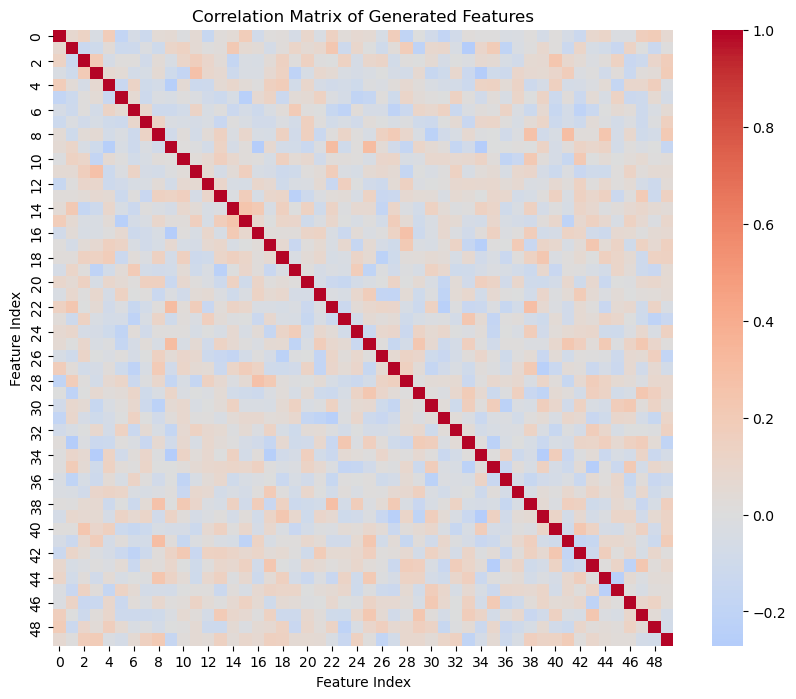

In [37]:
corr_matrix = np.corrcoef(X, rowvar=False)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)

plt.title('Correlation Matrix of Generated Features')
plt.xlabel('Feature Index')
plt.ylabel('Feature Index')
plt.show()

#### Task 3. Question 2

### Splitting 80% train / 20% test

In [38]:
def visualize_explained_variance(explained_variance, title='Explained Variance by Principal Component'):
    plt.figure(figsize=(10, 6))
    
    plt.bar(range(1, len(explained_variance) + 1), explained_variance, 
           color='steelblue', alpha=0.8, label='Individual')
    
    cumulative = np.cumsum(explained_variance)
    plt.plot(range(1, len(explained_variance) + 1), cumulative, 
            color="darkred", marker="o", linewidth=2.5, markersize=8, label='Cumulative')
    

    plt.axhline(0.8, linestyle='--', color='orange', alpha=0.7, linewidth=1.5, label='80% threshold')
    plt.axhline(0.9, linestyle='--', color='red', alpha=0.7, linewidth=1.5, label='90% threshold')

    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.title(title)
    plt.xticks(range(1, len(explained_variance) + 1))
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()


Number of PC for explaining 90% variance: 14
Reconstruction Error (Train): 0.1174
Reconstruction Error (Test): 0.2025


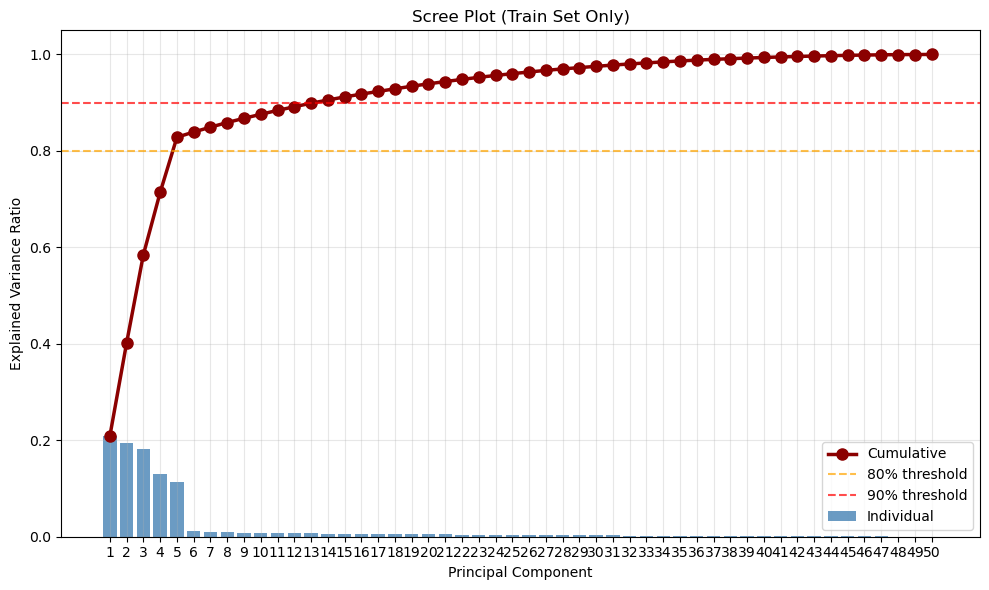

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

pca_full = PCA().fit(X_train)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
print(f"Number of PC for explaining 90% variance: {n_90}")

pca_90 = PCA(n_components=n_90)
X_train_pca = pca_90.fit_transform(X_train)
X_test_pca = pca_90.transform(X_test)

X_train_rec = pca_90.inverse_transform(X_train_pca)
X_test_rec = pca_90.inverse_transform(X_test_pca)

train_error = mean_squared_error(X_train, X_train_rec)
test_error = mean_squared_error(X_test, X_test_rec)

print(f"Reconstruction Error (Train): {train_error:.4f}")
print(f"Reconstruction Error (Test): {test_error:.4f}")

visualize_explained_variance(pca_full.explained_variance_ratio_, 'Scree Plot (Train Set Only)')
plt.show()

### Commentary
In order to explain 90% of variation within a train set, it is necessary to employ at least 32 principal components.
As for reconstruction errors on train and test datasets, the difference is 4x. The root mean square error between the original objects and their reconstruction for train data is not big that tells us that 32 PC describe our train dataset pretty good. In tur, the structure of variation in the test data is worse described by PCA trained on train dataset. The potential reason may lay on the shift distribution or key role of the rest 10% of variation which is not described by these 32 PC.

#### Task 3. Question 3

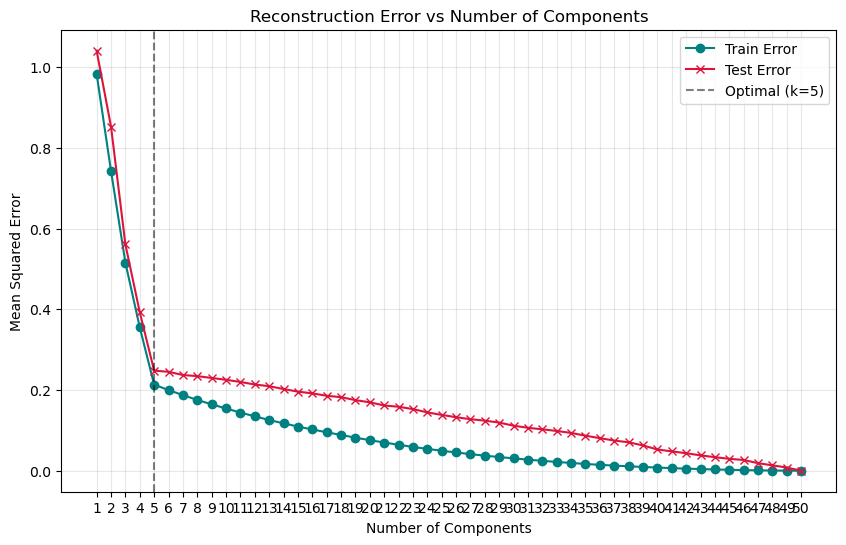

Reconstruction Errors for first 5 components:
k= 1: Train=0.98, Test=1.04
k= 2: Train=0.74, Test=0.85
k= 3: Train=0.52, Test=0.56
k= 4: Train=0.36, Test=0.39
k= 5: Train=0.21, Test=0.25


In [40]:
components_range = range(1, p+1)  # 1 to 50 components
train_errors = []
test_errors = []

for k in components_range:
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    X_train_rec = pca.inverse_transform(X_train_pca)
    X_test_rec = pca.inverse_transform(X_test_pca)
    
    train_err = mean_squared_error(X_train, X_train_rec)
    test_err = mean_squared_error(X_test, X_test_rec)
    
    train_errors.append(train_err)
    test_errors.append(test_err)

plt.figure(figsize=(10, 6))
plt.plot(components_range, train_errors, label='Train Error', marker='o', color='teal')
plt.plot(components_range, test_errors, label='Test Error', marker='x', color='crimson')

plt.title('Reconstruction Error vs Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Mean Squared Error')
plt.xticks(components_range)
plt.axvline(x=5, color='black', linestyle='--', alpha=0.5, label='Optimal (k=5)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Reconstruction Errors for first 5 components:")
for i, k in enumerate(range(1, 6)):
    print(f"k={k:2d}: Train={train_errors[i]:.2f}, Test={test_errors[i]:.2f}")

### Explanation:

Reconstruction errors decrease sharply for both train and test sets within the first 5PC and then smoothly for the following PCs (with test errors consistently higher). The first few principal components are equally effective on both sets because the data generation which comes from a standard normal distribution with identity covariance matrix (I_p). In this case, all directions of variation are equivalent, so PCA simply identifies sample specific noise that generalize well to the test set



#### Task 3. Question 4

To compare PCA performance across 3 tasks, let's take a look at the ratio of PCs which explain 90% of variation and the total number of PCs.

1 task: 33/39 ~ 85%

2 task: 15/49 ~ 32%

3 task 34/49 ~ 70% 

Gene expression scenario doesn't show the best results compressing the data to 33 PCs to capture 90% of original variation. Although biological genes have natural correlation structure, the variance is spread across many directions, so compression is only moderate. At the top of it, our dimension was assigned as (n) after applying PCA, formally the dimension is reduced from 1000 to 33 (but in the fact the compression happened to be from 39 to 33, where 39 is the number of non-null components after data centering). 

Partial correlation scenario is supposed to be considered as a benchmark for PCA application. Because of artificial data structure of high-correlated groups (based on the same latent factor), first 5 PCs capture more 82% of original variation, while the next 10 reach 90% level of explanation. This case is the most demonstrative because it shows how PCA manages with noise because multi-colleniarity.

The dataset with no correlation structure in the 3 task PCA shows worse results. The data is normally distributed with 50 independent features (because of identity matrix in setup), with small number of obs. that makes it extremely noisy. So, the variance is evenly distributed across PC, and PCA can not substantially reduce dimensionality without losing information.